
=== Calculating combined variance matrix across all models ===
AmazonCounterfactualClassification sorted_values [0.004405286343612335, 0.043478260869565216, 0.0023923444976076554, 0.002680965147453083, 0.0024330900243309003, 0.021739130434782608, 0.125, 0.002793296089385475, 0.0036101083032490976, 0.015625, 0.002347417840375587, 0.0048543689320388345, 0.003861003861003861, 0.0035587188612099642, 0.005747126436781609, 0.002325581395348837, 0.1, 0.0022522522522522522, 0.00196078431372549, 0.002331002331002331, 0.0026595744680851063, 0.0025380710659898475, 0.00211864406779661, 0.01020408163265306, 0.002570694087403599, 0.011904761904761904, 0.0056179775280898875, 0.002320185614849188, 0.00392156862745098, 0.0049504950495049506, 0.0024154589371980675, 0.045454545454545456, 0.0038022813688212928, 0.006666666666666667, 0.0024509803921568627, 0.013157894736842105, 0.00980392156862745, 0.0020876826722338203, 0.008, 0.002150537634408602, 0.004608294930875576, 0.006896551724137931, 0.0020120724

/tmp/ipykernel_1680372/1371039426.py:160: RuntimeWarning: divide by zero encountered in scalar divide
  sorted_values = [1 / it for it in sorted_indices]


✅ Combined heatmap saved: /home/linkco/exa/Useful-Embedding/data/analyze/stdmap_results/combined_variance_heatmap.png
✅ Combined variance matrix saved: /home/linkco/exa/Useful-Embedding/data/analyze/stdmap_results/combined_variance_matrix.csv
✅ Model count matrix saved: /home/linkco/exa/Useful-Embedding/data/analyze/stdmap_results/model_count_matrix.csv


/tmp/ipykernel_1680372/1371039426.py:295: RuntimeWarning: Mean of empty slice
  f.write(f"Mean variance (off-diagonal): {np.nanmean(average_variance_no_diag):.4f}\n")
/home/linkco/anaconda3/envs/omo10/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1680372/1371039426.py:297: RuntimeWarning: All-NaN slice encountered
  f.write(f"Min variance (off-diagonal): {np.nanmin(average_variance_no_diag):.4f}\n")
/tmp/ipykernel_1680372/1371039426.py:298: RuntimeWarning: All-NaN slice encountered
  f.write(f"Max variance (off-diagonal): {np.nanmax(average_variance_no_diag):.4f}\n\n")


ValueError: zero-size array to reduction operation minimum which has no identity

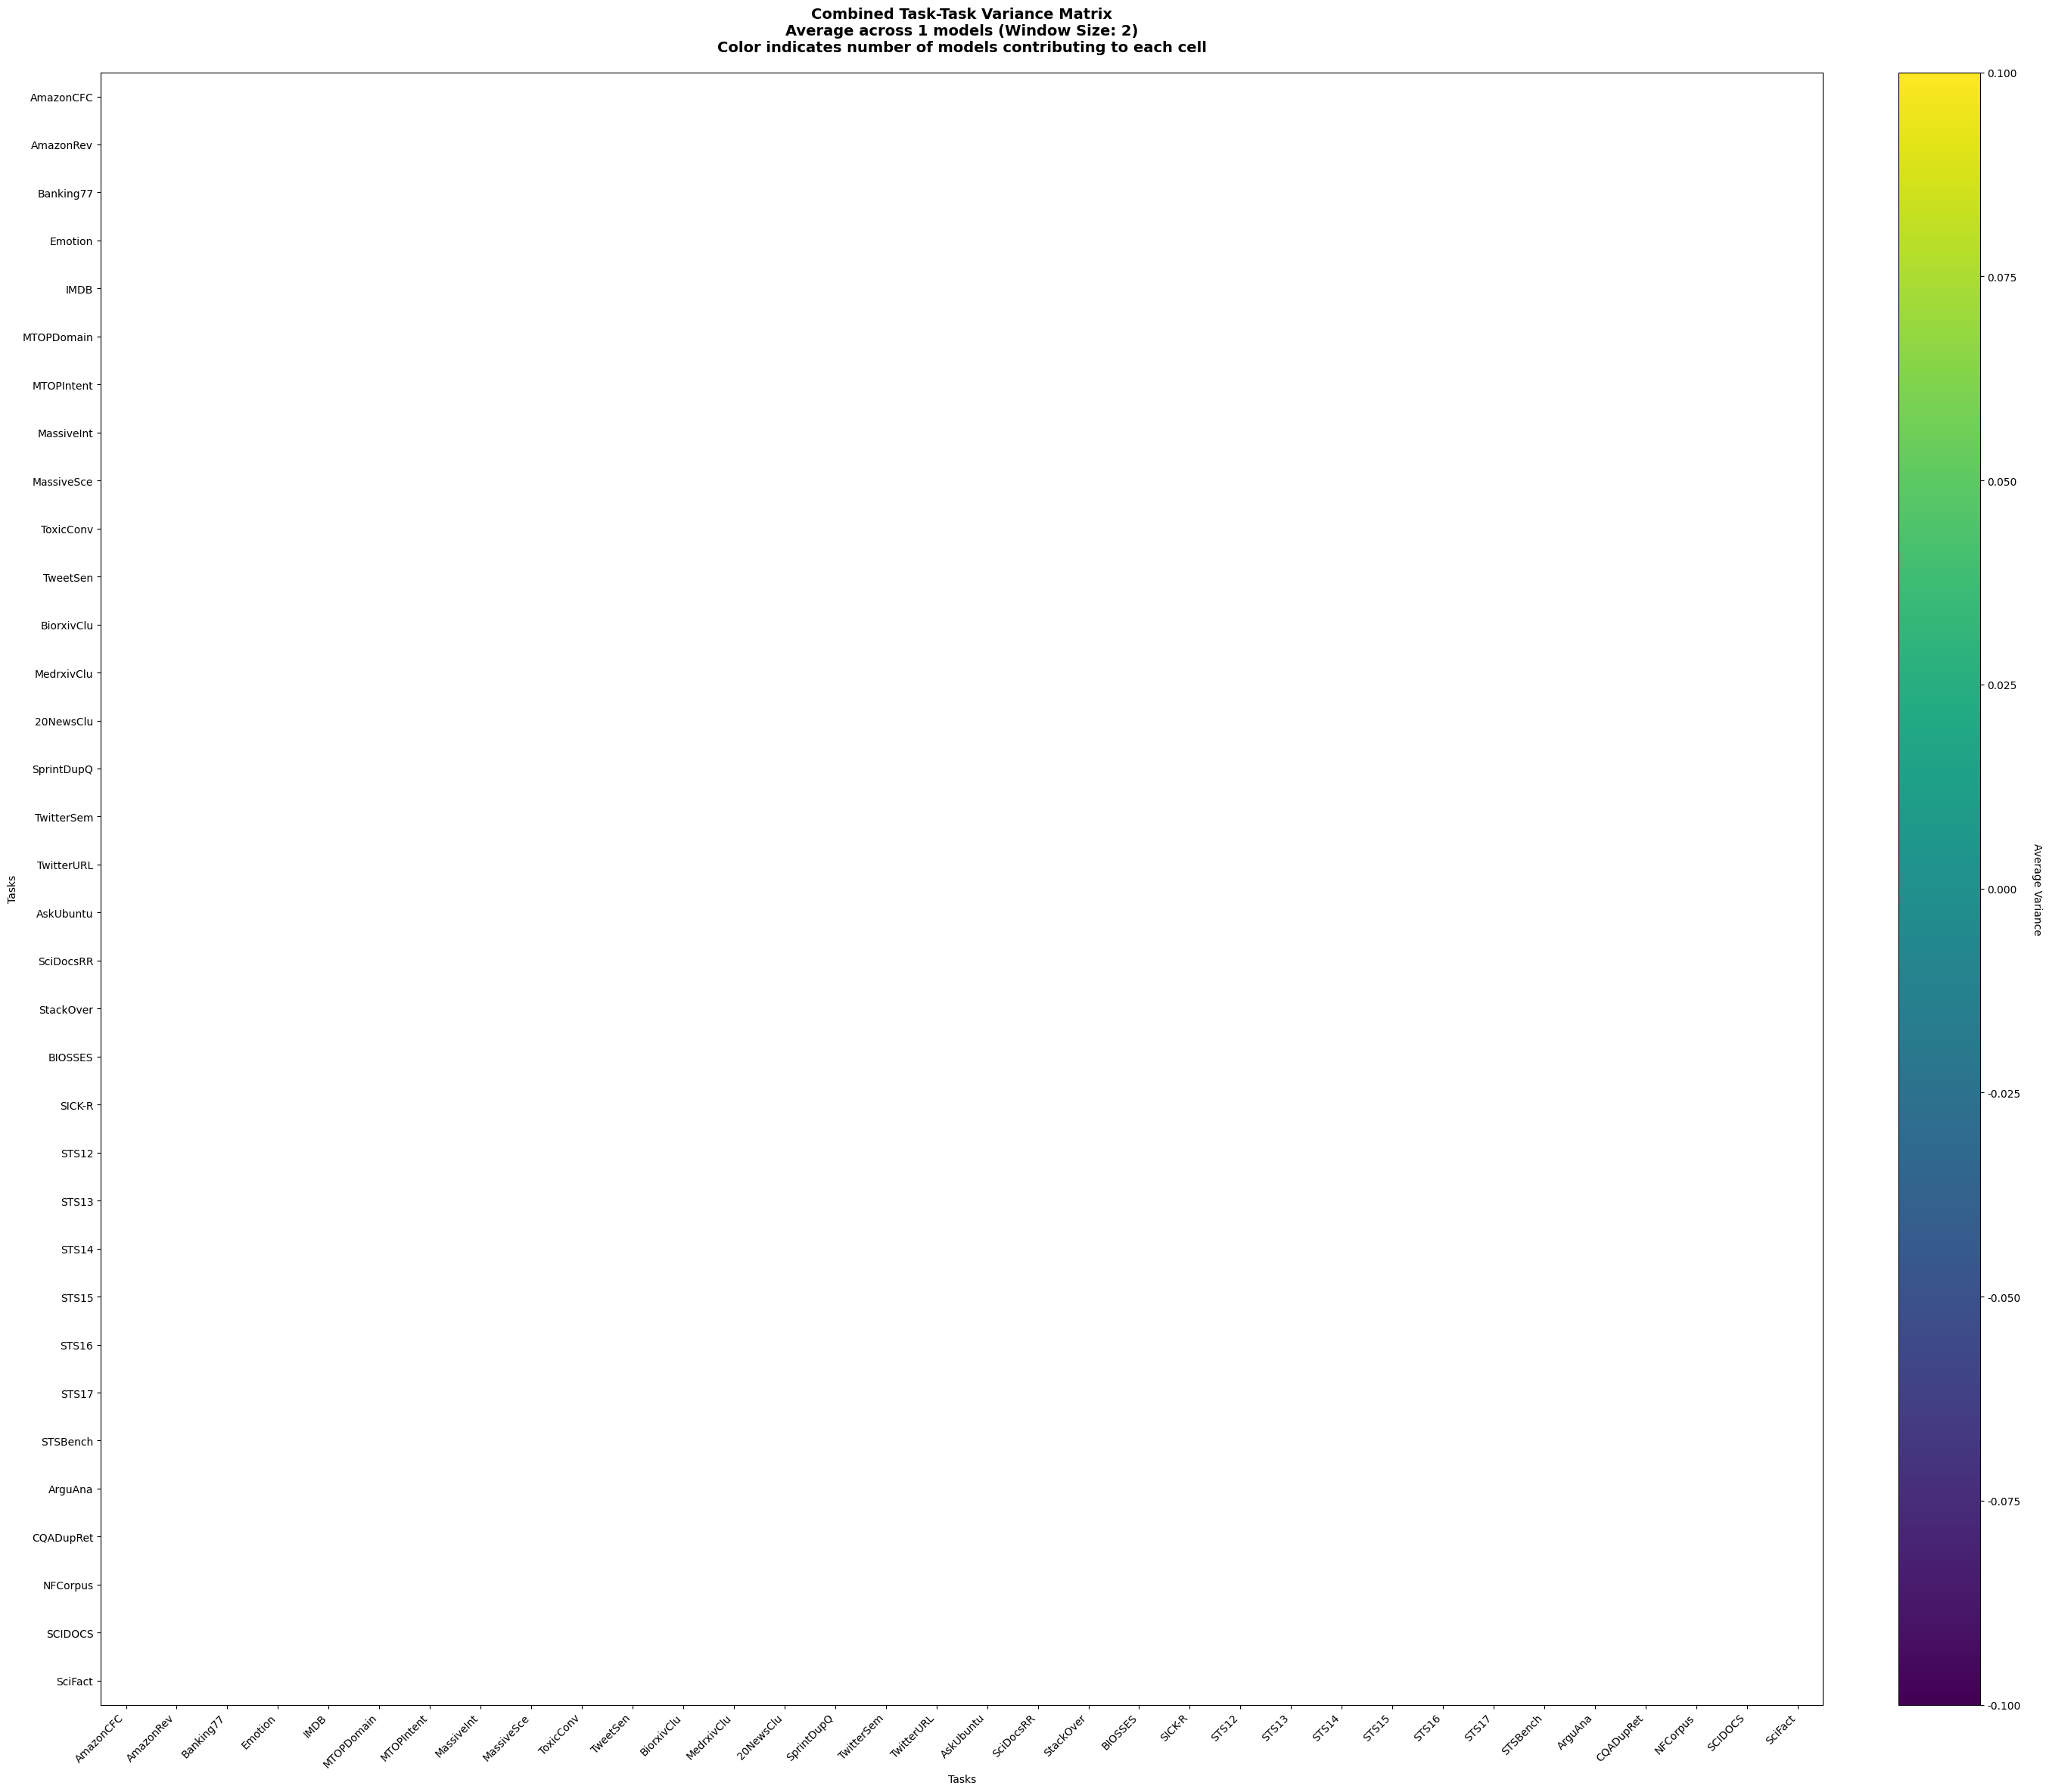

In [65]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ==================== Config ====================
folder_path = '/home/linkco/exa/Useful-Embedding/data/analyze/'
models_to_compare = ['stella_en_400M_v5']   # specify model(s)
analyz_split_win_size = 2                   # window size
output_dir = os.path.join(folder_path, "stdmap_results")
os.makedirs(output_dir, exist_ok=True)

# ==================== Font (English only) ====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== Task abbreviations ====================
task_abbreviations = {
    'AmazonCounterfactualClassification': 'AmazonCFC',
    'AmazonReviewsClassification': 'AmazonRev',
    'Banking77Classification': 'Banking77',
    'EmotionClassification': 'Emotion',
    'ImdbClassification': 'IMDB',
    'MTOPDomainClassification': 'MTOPDomain',
    'MTOPIntentClassification': 'MTOPIntent',
    'MassiveIntentClassification': 'MassiveInt',
    'MassiveScenarioClassification': 'MassiveSce',
    'ToxicConversationsClassification': 'ToxicConv',
    'TweetSentimentExtractionClassification': 'TweetSen',
    'BiorxivClusteringS2S': 'BiorxivClu',
    'MedrxivClusteringS2S': 'MedrxivClu',
    'TwentyNewsgroupsClustering': '20NewsClu',
    'SprintDuplicateQuestions': 'SprintDupQ',
    'TwitterSemEval2015': 'TwitterSem',
    'TwitterURLCorpus': 'TwitterURL',
    'AskUbuntuDupQuestions': 'AskUbuntu',
    'SciDocsRR': 'SciDocsRR',
    'StackOverflowDupQuestions': 'StackOver',
    'BIOSSES': 'BIOSSES',
    'SICK-R': 'SICK-R',
    'STS12': 'STS12',
    'STS13': 'STS13',
    'STS14': 'STS14',
    'STS15': 'STS15',
    'STS16': 'STS16',
    'STS17': 'STS17',
    'STSBenchmark': 'STSBench',
    'ArguAna': 'ArguAna',
    'CQADupstackEnglishRetrieval': 'CQADupRet',
    'NFCorpus': 'NFCorpus',
    'SCIDOCS': 'SCIDOCS',
    'SciFact': 'SciFact'
}

# ==================== Load data ====================
json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
all_models_data = {}

for file in json_files:
    model_name = file.replace(".json", "")
    if models_to_compare and model_name not in models_to_compare:
        continue
    file_path = os.path.join(folder_path, file)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    all_models_data[model_name] = data

if not all_models_data:
    raise ValueError("❌ No matching models found!")

# ==================== Tasks ====================
sample_model = next(iter(all_models_data.values()))
tasks = list(task_abbreviations.keys())



# ==================== Calculate combined variance matrix across all models ====================
print(f"\n=== Calculating combined variance matrix across all models ===")

# 初始化合并的方差矩阵
combined_variance_matrix = None
model_count_matrix = None  # 记录每个位置被多少个模型计算过
all_valid_tasks = None

# 第一次遍历：收集所有有效的任务
all_tasks_set = set()
for model_name, data in all_models_data.items():
    normalized_dict = {}
    
    for task_name in tasks:
        task_data = data["task_name"][task_name]
        split_data = task_data["split_win_size"].get(str(analyz_split_win_size), {})
        if not split_data:
            continue
            
        chunk_result_data = np.array(split_data['chunk_result'], dtype=float)
        n = len(chunk_result_data)
        if n == 0:
            continue
        
        # 用排序来作为权重
        sorted_indices = np.argsort(chunk_result_data)
        # normalized_indices = np.arange(n) / n
        # sorted_values = normalized_indices[sorted_indices]
        sorted_values = [1 / int(it + 1) for it in sorted_indices]
        
        # print(task_name, 'sorted_values', sorted_values)
        normalized_dict[task_name] = sorted_values
        
        all_tasks_set.add(task_name)


        # # 用数值来作为权重
        # print(np.mean(chunk_result_data))
        # mean_values = (chunk_result_data - np.mean(chunk_result_data)) / (np.max(chunk_result_data) - np.min(chunk_result_data))
        # normalized_dict[task_name] = mean_values
        
        # print(task_name, 'mean_values', mean_values)
        # all_tasks_set.add(task_name)
    
    print(f"Model {model_name}: {len(normalized_dict)} valid tasks")

# 按原始顺序排序任务
all_valid_tasks = [task for task in tasks if task in all_tasks_set]
num_tasks = len(all_valid_tasks)

if num_tasks < 2:
    print(f"⚠️ Need at least 2 valid tasks across all models, found {num_tasks}")
else:
    print(f"Total valid tasks across all models: {num_tasks}")
    
    # 初始化合并矩阵
    combined_variance_matrix = np.zeros((num_tasks, num_tasks))
    model_count_matrix = np.zeros((num_tasks, num_tasks), dtype=int)
    
    # 第二次遍历：计算每个模型的方差并累加
    for model_idx, (model_name, data) in enumerate(all_models_data.items()):
        print(f"Processing model {model_idx+1}/{len(all_models_data)}: {model_name}")
        
        normalized_dict = {}
        
        # 构建当前模型的归一化数据
        for task_name in all_valid_tasks:
            task_data = data["task_name"][task_name]
            split_data = task_data["split_win_size"].get(str(analyz_split_win_size), {})
            if not split_data:
                continue
                
            chunk_result_data = np.array(split_data['chunk_result'], dtype=float)
            n = len(chunk_result_data)
            if n == 0:
                continue

            
            # 用排序来作为权重
            sorted_indices = np.argsort(chunk_result_data)
            # normalized_indices = np.arange(n) / n
            # sorted_values = normalized_indices[sorted_indices]
            sorted_values = [1 / int(it + 1) for it in sorted_indices]
            
            # print(task_name, 'sorted_values', sorted_values)
            normalized_dict[task_name] = sorted_values


            # # 用数值来作为权重
            # mean_values = (chunk_result_data - np.mean(chunk_result_data)) / (np.max(chunk_result_data) - np.min(chunk_result_data))
            # normalized_dict[task_name] = mean_values
        
        if len(normalized_dict) < 2:
            print(f"  ⚠️ Skipping {model_name}: insufficient valid tasks")
            continue
        
        # 计算当前模型的方差矩阵
        current_variance_matrix = np.full((num_tasks, num_tasks), np.nan)
        
        for i in range(num_tasks):
            task_i = all_valid_tasks[i]
            if task_i not in normalized_dict:
                continue
                
            data_i = normalized_dict[task_i]
            len_i = len(data_i)
            
            for j in range(num_tasks):
                task_j = all_valid_tasks[j]
                if task_j not in normalized_dict:
                    continue
                    
                data_j = normalized_dict[task_j]
                len_j = len(data_j)
                
                # 找到最小长度进行对齐
                min_len = min(len_i, len_j)
                
                if min_len > 0:
                    # 截取相同长度的数据
                    aligned_i = data_i[:min_len]
                    aligned_j = data_j[:min_len]
                    
                    # 计算方差
                    current_variance_matrix[i, j] = np.var(aligned_i - aligned_j)
        
        # 累加到总矩阵中
        valid_mask = ~np.isnan(current_variance_matrix)
        combined_variance_matrix[valid_mask] += current_variance_matrix[valid_mask]
        model_count_matrix[valid_mask] += 1
    
    # 计算平均方差矩阵
    average_variance_matrix = np.zeros((num_tasks, num_tasks))
    average_variance_matrix[:] = np.nan
    
    valid_positions = model_count_matrix > 0
    average_variance_matrix[valid_positions] = combined_variance_matrix[valid_positions] / model_count_matrix[valid_positions]
    
    # 排除对角线元素用于统计
    diagonal_mask = np.eye(num_tasks, dtype=bool)
    average_variance_no_diag = average_variance_matrix.copy()
    average_variance_no_diag[diagonal_mask] = np.nan
    
    # ==================== Plot combined heatmap ====================
    task_labels = [task_abbreviations.get(task, task) for task in all_valid_tasks]
    
    plt.figure(figsize=(max(14, num_tasks * 0.8), max(12, num_tasks * 0.7)))
    
    # 使用imshow创建热力图，排除对角线
    mask = np.isnan(average_variance_no_diag)
    variance_matrix_masked = np.ma.array(average_variance_matrix, mask=mask)
    
    im = plt.imshow(variance_matrix_masked, cmap='viridis', aspect='auto')
    
    # 添加颜色条
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label('Average Variance', rotation=270, labelpad=20)
    
    # 设置坐标轴
    plt.xticks(np.arange(num_tasks), task_labels, rotation=45, ha='right')
    plt.yticks(np.arange(num_tasks), task_labels)
    plt.xlabel('Tasks')
    plt.ylabel('Tasks')
    
    # 添加标题
    plt.title(f'Combined Task-Task Variance Matrix\n'
              f'Average across {len(all_models_data)} models (Window Size: {analyz_split_win_size})\n'
              f'Color indicates number of models contributing to each cell', 
              pad=20, fontsize=14, fontweight='bold')
    
    # 在热力图上显示数值和模型数量
    for i in range(num_tasks):
        for j in range(num_tasks):
            if not mask[i, j]:
                value_text = f'{average_variance_matrix[i, j]:.3f}'
                count_text = f'({model_count_matrix[i, j]})'
                full_text = f'{value_text}\n{count_text}'
                
                # 根据背景色调整文字颜色
                bg_color = variance_matrix_masked[i, j]
                text_color = 'w' if bg_color > np.nanmean(average_variance_matrix) / 2 else 'k'
                
                plt.text(j, i, full_text, ha="center", va="center", 
                        color=text_color, fontsize=7, linespacing=0.8)
    
    plt.tight_layout()
    
    # ==================== Save combined results ====================
    # 保存热力图
    heatmap_path = os.path.join(output_dir, "combined_variance_heatmap.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"✅ Combined heatmap saved: {heatmap_path}")
    
    # 保存平均方差矩阵为CSV
    combined_df = pd.DataFrame(average_variance_matrix, 
                              index=task_labels, 
                              columns=task_labels)
    csv_path = os.path.join(output_dir, "combined_variance_matrix.csv")
    combined_df.to_csv(csv_path)
    print(f"✅ Combined variance matrix saved: {csv_path}")
    
    # 保存模型计数矩阵
    count_df = pd.DataFrame(model_count_matrix,
                           index=task_labels,
                           columns=task_labels)
    count_csv_path = os.path.join(output_dir, "model_count_matrix.csv")
    count_df.to_csv(count_csv_path)
    print(f"✅ Model count matrix saved: {count_csv_path}")
    
    # 保存统计信息
    stats_path = os.path.join(output_dir, "combined_variance_stats.txt")
    with open(stats_path, 'w') as f:
        f.write(f"Combined Variance Statistics (Average across {len(all_models_data)} models)\n")
        f.write("=" * 70 + "\n")
        f.write(f"Models included: {', '.join(all_models_data.keys())}\n")
        f.write(f"Total tasks: {num_tasks}\n")
        f.write(f"Total task pairs: {num_tasks * num_tasks}\n")
        
        valid_off_diag = np.sum(~mask) - num_tasks
        f.write(f"Valid off-diagonal pairs: {valid_off_diag}\n")
        f.write(f"Mean variance (off-diagonal): {np.nanmean(average_variance_no_diag):.4f}\n")
        f.write(f"Std variance (off-diagonal): {np.nanstd(average_variance_no_diag):.4f}\n")
        f.write(f"Min variance (off-diagonal): {np.nanmin(average_variance_no_diag):.4f}\n")
        f.write(f"Max variance (off-diagonal): {np.nanmax(average_variance_no_diag):.4f}\n\n")
        
        # 找到方差最大和最小的任务对（排除对角线）
        flat_indices = np.argsort(average_variance_no_diag.flatten())
        valid_off_diag_mask = ~mask.flatten()
        valid_off_diag_indices = flat_indices[valid_off_diag_mask[flat_indices]]
        
        if len(valid_off_diag_indices) > 0:
            min_idx = np.unravel_index(valid_off_diag_indices[0], average_variance_matrix.shape)
            max_idx = np.unravel_index(valid_off_diag_indices[-1], average_variance_matrix.shape)
            
            f.write("Most similar task pair (min variance):\n")
            f.write(f"  {all_valid_tasks[min_idx[0]]} vs {all_valid_tasks[min_idx[1]]}: {average_variance_matrix[min_idx]:.4f}\n")
            f.write(f"  Contributed by {model_count_matrix[min_idx]} models\n\n")
            
            f.write("Most dissimilar task pair (max variance):\n")
            f.write(f"  {all_valid_tasks[max_idx[0]]} vs {all_valid_tasks[max_idx[1]]}: {average_variance_matrix[max_idx]:.4f}\n")
            f.write(f"  Contributed by {model_count_matrix[max_idx]} models\n\n")
        
        # 添加模型覆盖统计
        f.write("Model coverage statistics:\n")
        f.write(f"  Minimum models per cell: {np.min(model_count_matrix[valid_positions])}\n")
        f.write(f"  Maximum models per cell: {np.max(model_count_matrix[valid_positions])}\n")
        f.write(f"  Average models per cell: {np.mean(model_count_matrix[valid_positions]):.1f}\n")
    
    print(f"✅ Combined statistics saved: {stats_path}")
    plt.show()

print(f"\n🎉 All combined results saved to: {output_dir}")

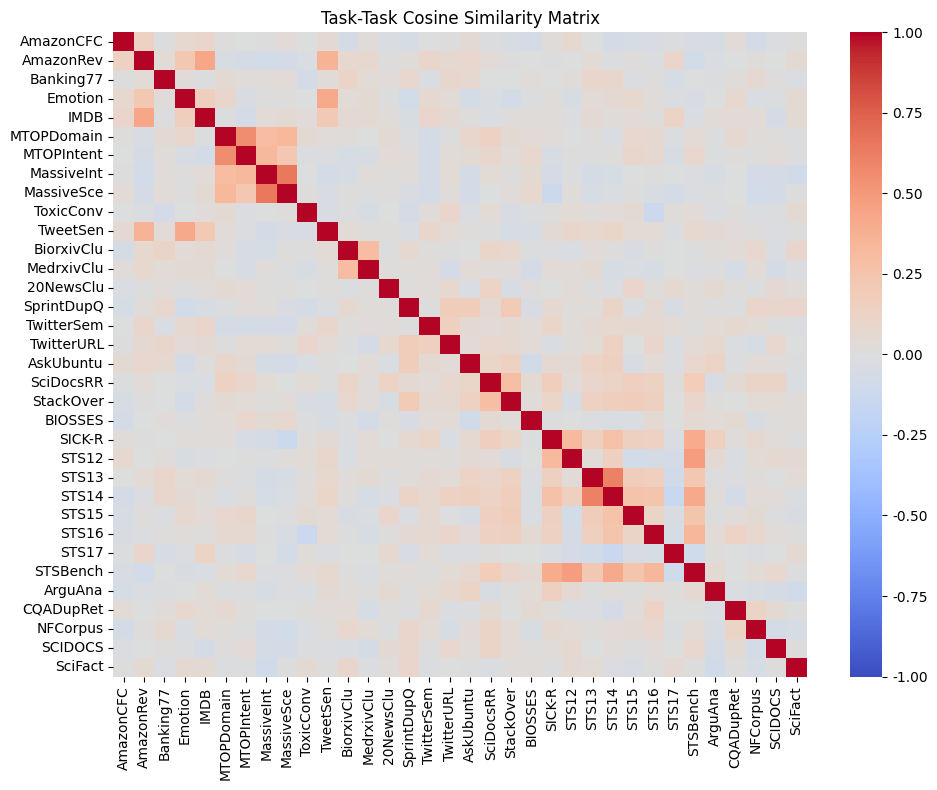

In [54]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# 假设 normalized_dict 已经存有各任务的权重向量
task_vectors = [normalized_dict[task] for task in all_valid_tasks]
similarity_matrix = cosine_similarity(task_vectors)

# 可视化相似性
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, xticklabels=task_labels, yticklabels=task_labels, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Task-Task Cosine Similarity Matrix")
plt.tight_layout()
plt.show()


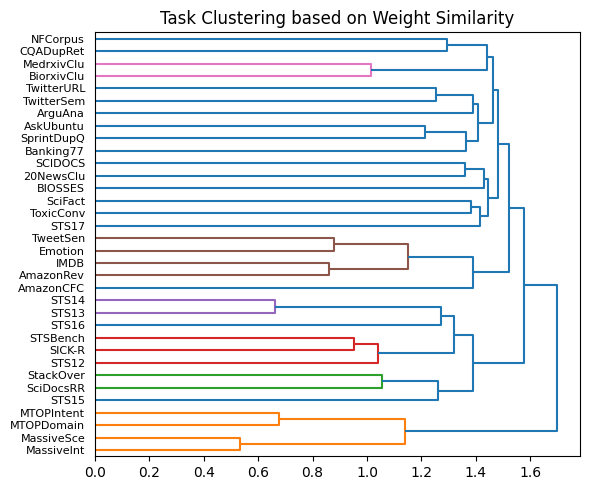

In [55]:
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

linked = linkage(1 - similarity_matrix, 'average')  # 相似度越高，距离越小
plt.figure(figsize=(6, 5))
dendrogram(linked, labels=task_labels, orientation='right')
plt.title("Task Clustering based on Weight Similarity")
# plt.xlabel("Distance (1 - cosine similarity)")
plt.tight_layout()
plt.show()


/home/linkco/exa/Useful-Embedding/data/analyze/stdmap_results/task_cluster_tree.png


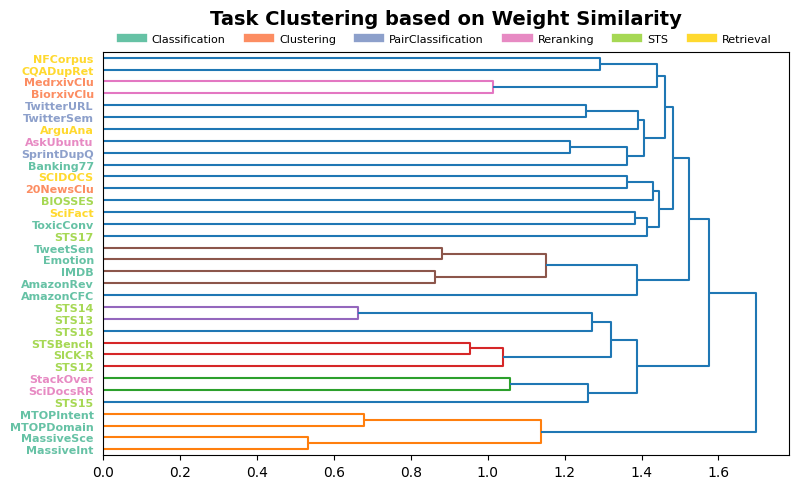

In [56]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 1. 计算层次聚类 =====
linked = linkage(1 - similarity_matrix, method='average')

# ===== 2. 绘制树状图 =====
plt.figure(figsize=(8, 5))
ddata = dendrogram(linked, labels=task_labels, orientation='right')
plt.title("Task Clustering based on Weight Similarity", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()

# ===== 3. 定义任务类别颜色 =====
task_categories = {
    "Classification": [
        'AmazonCounterfactualClassification',
        'AmazonReviewsClassification', 'Banking77Classification',
        'EmotionClassification', 'ImdbClassification',
        'MTOPDomainClassification', 'MTOPIntentClassification',
        'MassiveIntentClassification', 'MassiveScenarioClassification',
        'ToxicConversationsClassification', 'TweetSentimentExtractionClassification'
    ],
    "Clustering": [
        'BiorxivClusteringS2S', 'MedrxivClusteringS2S',
        'TwentyNewsgroupsClustering'
    ],
    "PairClassification": [
        'SprintDuplicateQuestions', 'TwitterSemEval2015', 'TwitterURLCorpus'
    ],
    "Reranking": [
        'AskUbuntuDupQuestions', 'SciDocsRR', 'StackOverflowDupQuestions'
    ],
    "STS": [
        'BIOSSES', 'SICK-R', 'STS12', 'STS13', 'STS14', 'STS15',
        'STS16', 'STS17', 'STSBenchmark'
    ],
    "Retrieval": [
        'ArguAna', 'CQADupstackEnglishRetrieval',
        'NFCorpus', 'SCIDOCS', 'SciFact'
    ],
}

for cat, tasks_in_cat in task_categories.items():
    task_categories[cat] = [task_abbreviations[it] for it in tasks_in_cat]

# ==================== 颜色定义（固定或自动生成） ====================
palette = sns.color_palette("Set2", len(task_categories))  # 自动生成柔和配色
category_colors = dict(zip(task_categories.keys(), palette))

# ==================== 任务→类别→颜色 映射 ====================
task_to_category = {}
for cat, tasks_in_cat in task_categories.items():
    for t in tasks_in_cat:
        task_to_category[t] = cat

task_to_color = {t: category_colors.get(task_to_category.get(t, ""), "gray") for t in task_labels}

# ===== 6. 修改标签颜色 =====
ax = plt.gca()
ylabels = ax.get_yticklabels()
for label in ylabels:
    task_name = label.get_text()
    color = task_to_color.get(task_name, "black")
    label.set_color(color)
    label.set_fontweight("bold")

# ===== 7. 添加图例（顶部一行） =====
handles = [
    plt.Line2D([0], [0], color=color, lw=6, label=cat)
    for cat, color in category_colors.items()
]

plt.legend(
    handles=handles,
    # title="Task Categories",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),   # 向上移动一点
    ncol=len(category_colors),    # 横向排列
    frameon=False,
    fontsize=8,
    title_fontsize=9
)



task_cluster_tree_path = os.path.join(output_dir, "task_cluster_tree.png")
plt.savefig(task_cluster_tree_path, dpi=300, bbox_inches='tight')
print(task_cluster_tree_path)

plt.show()


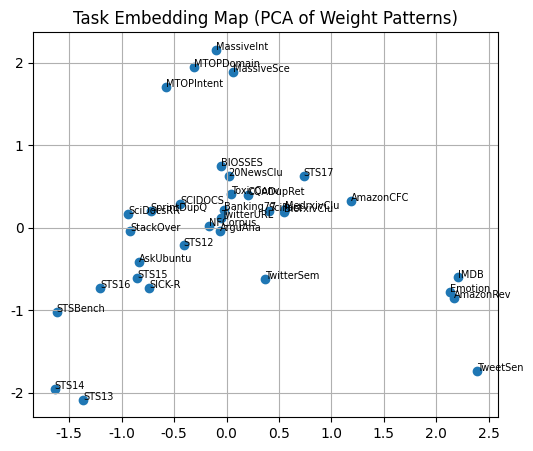

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
task_embeddings = pca.fit_transform(task_vectors)

plt.figure(figsize=(6, 5))
plt.scatter(task_embeddings[:,0], task_embeddings[:,1])

for i, label in enumerate(task_labels):
    plt.text(task_embeddings[i,0], task_embeddings[i,1], label, fontsize=7)

plt.title("Task Embedding Map (PCA of Weight Patterns)")
# plt.xlabel("PCA-1")
# plt.ylabel("PCA-2")
plt.grid(True)
plt.show()


/home/linkco/exa/Useful-Embedding/data/analyze/stdmap_results/task_cluster_map.png


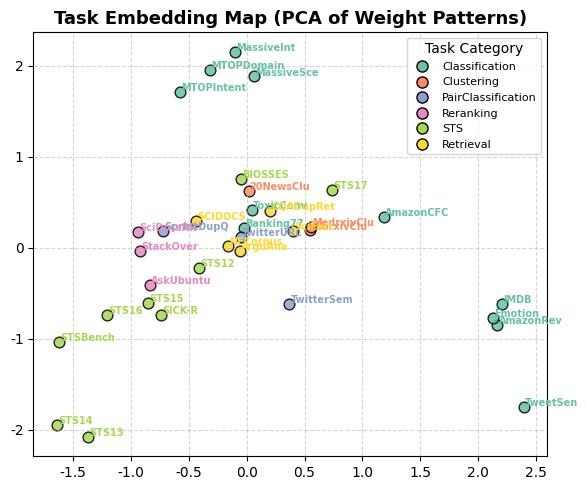

In [58]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== Task categories ====================
task_categories = {
    "Classification": [
        'AmazonCounterfactualClassification', 'AmazonReviewsClassification', 'Banking77Classification',
        'EmotionClassification', 'ImdbClassification', 'MTOPDomainClassification',
        'MTOPIntentClassification', 'MassiveIntentClassification', 'MassiveScenarioClassification',
        'ToxicConversationsClassification', 'TweetSentimentExtractionClassification'
    ],
    "Clustering": [
        'BiorxivClusteringS2S', 'MedrxivClusteringS2S', 'TwentyNewsgroupsClustering'
    ],
    "PairClassification": [
        'SprintDuplicateQuestions', 'TwitterSemEval2015', 'TwitterURLCorpus'
    ],
    "Reranking": [
        'AskUbuntuDupQuestions', 'SciDocsRR', 'StackOverflowDupQuestions'
    ],
    "STS": [
        'BIOSSES', 'SICK-R', 'STS12', 'STS13', 'STS14', 'STS15', 'STS16', 'STS17', 'STSBenchmark'
    ],
    "Retrieval": [
        'ArguAna', 'CQADupstackEnglishRetrieval', 'NFCorpus', 'SCIDOCS', 'SciFact'
    ],
}

for cat, tasks_in_cat in task_categories.items():
    task_categories[cat] = [task_abbreviations[it] for it in tasks_in_cat]

# ==================== 颜色定义（固定或自动生成） ====================
palette = sns.color_palette("Set2", len(task_categories))  # 自动生成柔和配色
category_colors = dict(zip(task_categories.keys(), palette))

# ==================== 任务→类别→颜色 映射 ====================
task_to_category = {}
for cat, tasks_in_cat in task_categories.items():
    for t in tasks_in_cat:
        task_to_category[t] = cat

task_to_color = {t: category_colors.get(task_to_category.get(t, ""), "gray") for t in task_labels}

# ==================== PCA 降维 ====================
pca = PCA(n_components=2)
task_embeddings = pca.fit_transform(task_vectors)

# ==================== 绘图 ====================
plt.figure(figsize=(6, 5))
for i, task in enumerate(task_labels):
    color = task_to_color[task]
    plt.scatter(task_embeddings[i, 0], task_embeddings[i, 1], c=[color], s=60, edgecolors='k', alpha=0.85)
    abbrev = task_abbreviations.get(task, task)
    plt.text(task_embeddings[i, 0]+0.01, task_embeddings[i, 1]+0.01, abbrev,
             fontsize=7, color=color, fontweight='bold')

plt.title("Task Embedding Map (PCA of Weight Patterns)", fontsize=13, fontweight="bold")
# plt.xlabel("PCA-1")
# plt.ylabel("PCA-2")
plt.grid(True, linestyle='--', alpha=0.5)

# ==================== 图例 ====================
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=cat,
               markerfacecolor=color, markersize=8, markeredgecolor='k')
    for cat, color in category_colors.items()
]
plt.legend(handles=handles, title="Task Category", loc='best', fontsize=8)

plt.tight_layout()

task_cluster_map_path = os.path.join(output_dir, "task_cluster_map.png")
plt.savefig(task_cluster_map_path, dpi=300, bbox_inches='tight')
print(task_cluster_map_path)

plt.show()


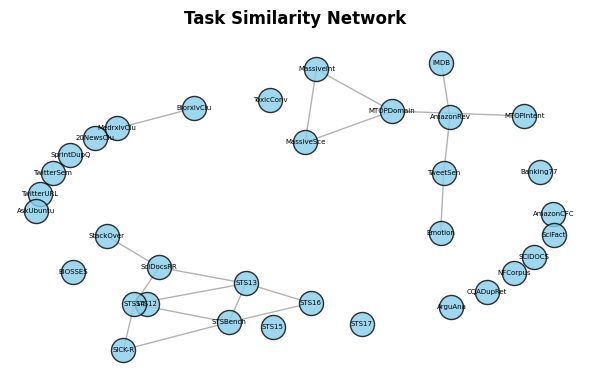

In [51]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 构建图
G = nx.Graph()
for i in range(len(task_labels)):
    G.add_node(task_labels[i])
for i in range(len(task_labels)):
    for j in range(i+1, len(task_labels)):
        if similarity_matrix[i, j] > 0.3:
            G.add_edge(task_labels[i], task_labels[j], weight=similarity_matrix[i, j])

# ==== 改进布局 ====
pos = nx.kamada_kawai_layout(G)  # 更稳定的全局布局
# 可加扰动
for key in pos:
    pos[key] += np.random.normal(scale=0.01, size=2)

# ==== 绘制 ====
plt.figure(figsize=(6, 4))
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=300, alpha=0.8, edgecolors='k')
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=5)

plt.title("Task Similarity Network", fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
